float32 relative error: 2.457e-03
float64 relative error: 5.110e-14


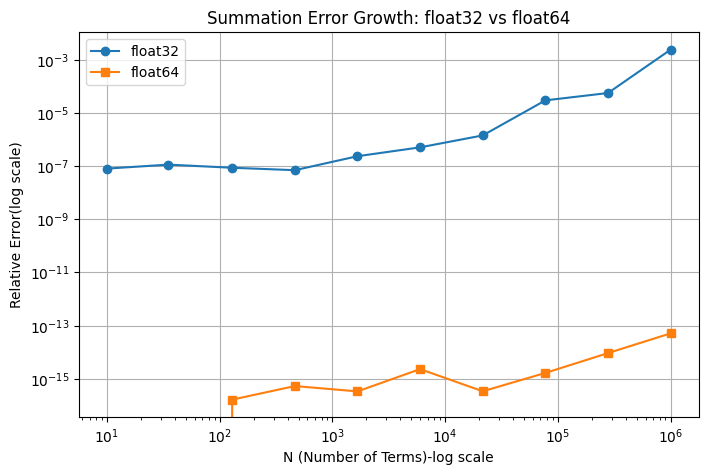

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from decimal import Decimal, getcontext


# High precision setup
getcontext().prec = 50

# -------------------------
# Part A: Single large sum
# -------------------------
N = 1_000_000

# High-precision reference
exact = float(sum(Decimal(1)/Decimal(k) for k in range(1, N+1)))

# float32 and float64 sums
s32 = np.float32(0)
s64 = np.float64(0)

for k in range(1, N+1):
    s32 += np.float32(1.0/k)
    s64 += np.float64(1.0/k)

# Relative errors
err32 = abs(s32 - exact) / exact
err64 = abs(s64 - exact) / exact

print(f"float32 relative error: {err32:.3e}")
print(f"float64 relative error: {err64:.3e}")


# -------------------------
# Part B: Error growth plot
# -------------------------
Ns = np.logspace(1, 6, 10, dtype=int)

errors32 = []
errors64 = []

for n in Ns:
    exact = float(sum(Decimal(1)/Decimal(k) for k in range(1, n+1)))

    s32 = np.float32(0)
    s64 = np.float64(0)

    for k in range(1, n+1):
        s32 += np.float32(1.0/k)
        s64 += np.float64(1.0/k)

    errors32.append(abs(s32 - exact) / exact)
    errors64.append(abs(s64 - exact) / exact)

# Plot
plt.figure(figsize=(8,5))
plt.plot(Ns, errors32, marker='o', label='float32')
plt.plot(Ns, errors64, marker='s', label='float64')

plt.xscale('log')
plt.yscale('log')

plt.xlabel("N (Number of Terms)-log scale")
plt.ylabel("Relative Error(log scale)")
plt.title("Summation Error Growth: float32 vs float64")
plt.legend()
plt.grid(True)

plt.show()